In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
# ============================================
# TESLA SALES & PRODUCTION ML PIPELINE
# ============================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore")

# ============================================
# 2. LOAD DATASET
# ============================================

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)       

In [3]:
# ============================================
# 3. DATASET INFORMATION
# ============================================

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)


Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Data Types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [4]:
# ============================================
# 4. DATA CLEANING
# ============================================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing numeric values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

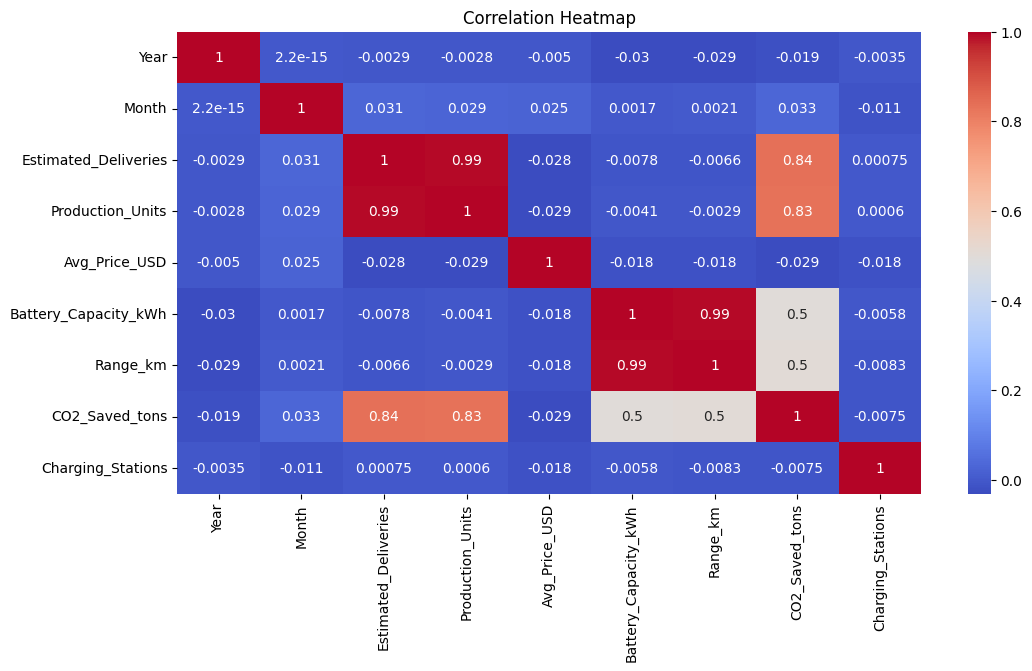

In [5]:
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# Correlation Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


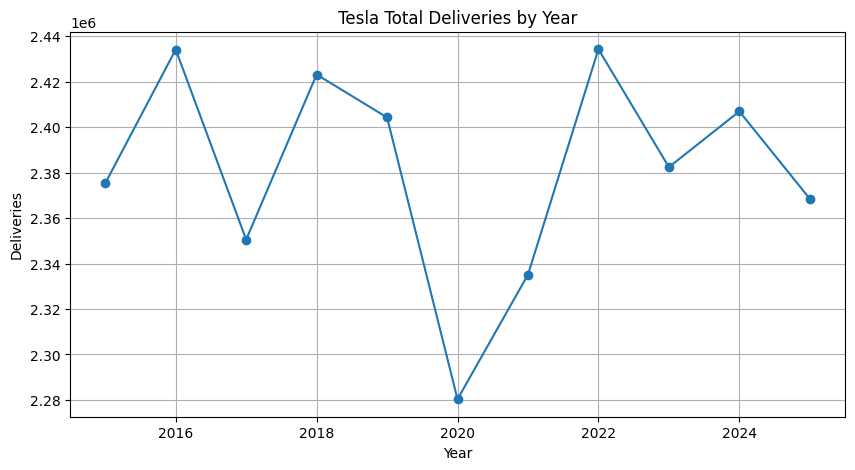

In [6]:
# Total Deliveries by Year
yearly_delivery = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_delivery.index, yearly_delivery.values, marker='o')
plt.title("Tesla Total Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Deliveries")
plt.grid(True)
plt.show()

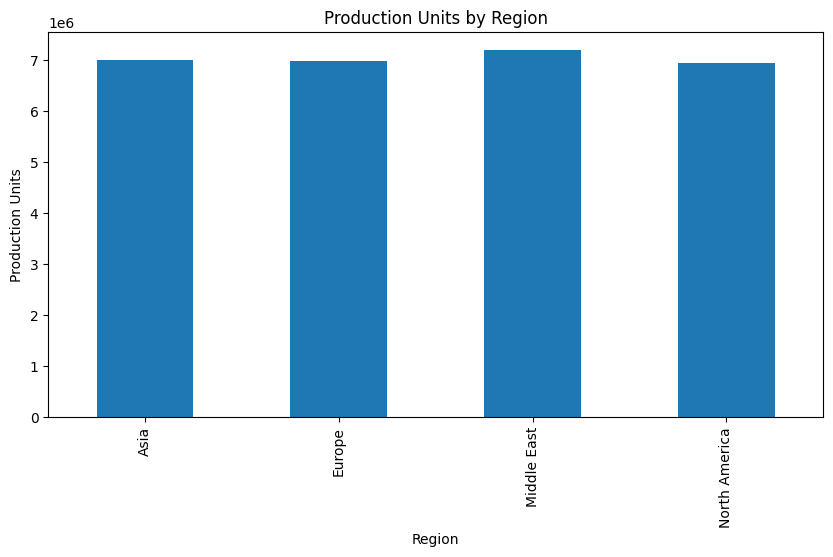

In [7]:
region_prod = df.groupby("Region")["Production_Units"].sum()

plt.figure(figsize=(10,5))
region_prod.plot(kind='bar')
plt.title("Production Units by Region")
plt.ylabel("Production Units")
plt.show()

In [8]:
# 6. FEATURE ENGINEERING
# ============================================

# Encode categorical columns
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Feature & Target
X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# 7. TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# 8. LINEAR REGRESSION MODEL
# ============================================

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\n===== Linear Regression =====")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))


===== Linear Regression =====
MAE: 310.13002154681993
RMSE: 383.5765698703893
R2 Score: 0.9901296027802068


In [11]:
# 9. RANDOM FOREST REGRESSOR
# ============================================

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\n===== Random Forest =====")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))



===== Random Forest =====
MAE: 323.6545454545455
RMSE: 409.5386617951036
R2 Score: 0.9887482440967752


In [12]:
# 10. HYPERPARAMETER TUNING
# ============================================

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [13]:
# Best Model Prediction
best_pred = best_model.predict(X_test)

print("\n===== Tuned Random Forest =====")
print("MAE:", mean_absolute_error(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R2 Score:", r2_score(y_test, best_pred))


===== Tuned Random Forest =====
MAE: 323.6545454545455
RMSE: 409.5386617951036
R2 Score: 0.9887482440967752



Top Features:
              Feature  Importance
4    Production_Units    0.990785
8      CO2_Saved_tons    0.002348
7            Range_km    0.001415
5       Avg_Price_USD    0.001338
10  Charging_Stations    0.001170


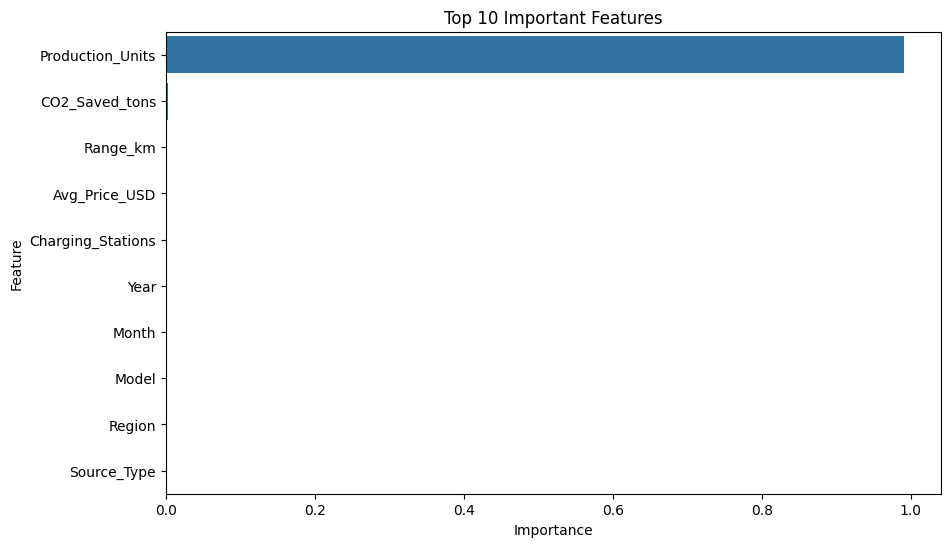

In [14]:
# 11. FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print("\nTop Features:")
print(importance.head())

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)
plt.title("Top 10 Important Features")
plt.show()

In [15]:
# 12. TIME SERIES FORECASTING
# ============================================

# Monthly Deliveries Trend
monthly_delivery = df.groupby("Month")["Estimated_Deliveries"].sum()

# Forecasting
model = ExponentialSmoothing(
    monthly_delivery,
    trend='add',
    seasonal=None
).fit()

forecast = model.forecast(6)

print("\nNext 6 Month Forecast:")
print(forecast)



Next 6 Month Forecast:
12    2.236470e+06
13    2.244906e+06
14    2.253343e+06
15    2.261780e+06
16    2.270216e+06
17    2.278653e+06
dtype: float64


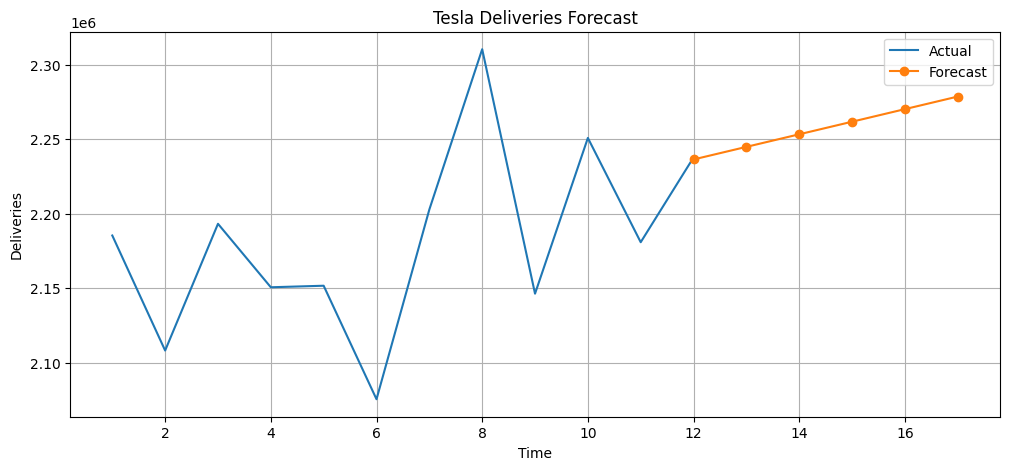

In [16]:
# Plot Forecast
plt.figure(figsize=(12,5))

plt.plot(monthly_delivery.index,
         monthly_delivery.values,
         label="Actual")

future_index = range(
    len(monthly_delivery),
    len(monthly_delivery) + 6
)

plt.plot(
    future_index,
    forecast.values,
    marker='o',
    label="Forecast"
)

plt.title("Tesla Deliveries Forecast")
plt.xlabel("Time")
plt.ylabel("Deliveries")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# 13. SAVE CLEANED DATA
# ============================================

df.to_csv("cleaned_tesla_dataset.csv", index=False)

print("\nPipeline Completed Successfully!")


Pipeline Completed Successfully!
